### Exploratory Data Analysis for Research Question 4 and 5
- Q4: Is formal saving associated with greater financial resilience in Thailand, and has this relationship changed between 2021 and 2024? 
 

- Q5: Is greater financial inclusion associated with greater financial resilience in Thailand?

Financial inclusion -> Access ->  Ownership -> Usage->Saving / Borrowing -> Financial health

In [3]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

sns.set(style="whitegrid", context="notebook") 
plt.rcParams['figure.dpi'] = 100 
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_rows', 12)

df4 = pd.read_csv("data_cleaned.csv")

In [5]:
df4.head()

,wage_payment_method,no_account_family_member,debit_card_ownership,ever_had_mobile_money_account,survey_year,ever_had_bank_account,...,received_transfers,no_account_insufficient_funds,codes_found,gender,age_group,education_original
0,2.0,NaN,2.0,2.0,2021,NaN,...,1.0,NaN,False,Female,23_29,3.0
1,2.0,NaN,1.0,1.0,2021,NaN,...,1.0,NaN,False,Male,30_39,3.0
2,NaN,NaN,NaN,2.0,2021,NaN,...,1.0,NaN,False,Female,40_49,3.0
3,NaN,NaN,NaN,2.0,2021,NaN,...,1.0,NaN,False,Female,40_49,3.0
4,NaN,NaN,2.0,1.0,2021,NaN,...,1.0,NaN,False,Male,30_39,3.0


In [6]:
df4["account_usage"] = df4["account_usage"].astype("Int64") 

In [7]:
print(df4["account_usage"].value_counts(dropna=False))

account_usage
1       1130
2        477
<NA>     163
3        155
4         63
6         19
5         10
Name: count, dtype: Int64


In [9]:
account_usage_labels = {
    1: "Weekly deposit",
    2: "Monthly deposit",
    3: "Less than monthly deposit",
    4: "Never deposited",
    5: "Don't know",
    6: "Refused"
}

# account_usage is only asked of account owners, so non-owners are NA 
df4["account_usage_label"] = (
    df4["account_usage"]
    .map(account_usage_labels)
    .fillna("Not applicable (no account)")
)

print(df4["account_usage_label"].value_counts(dropna=False))

account_usage_label
Weekly deposit                 1130
Monthly deposit                 477
Not applicable (no account)     163
Less than monthly deposit       155
Never deposited                  63
Refused                          19
Don't know                       10
Name: count, dtype: int64


### Financial Health Indicator

In [10]:
df_health = df4[df4["financial_health_indicator"].isin([1, 2, 3, 4, 5, 6, 7, 8])].copy()

In [11]:
print(df4["financial_health_indicator"].value_counts(dropna=False))

financial_health_indicator
NaN    458
4.0    444
3.0    369
1.0    344
2.0    200
5.0    113
6.0     36
7.0     33
8.0     20
Name: count, dtype: int64


In [12]:
financial_health_labels = {
    1: "Not enough money for old age",
    2: "Not enough money for business",
    3: "Not enough money for medical costs after a serious illness or accident",
    4: "Not enough money for monthly expenses",
    5: "Not enough money for school or education fees",
    6: "Not enough money for another reason",
    7: "Don't know",
    8: "Refused",
}

# Missing values represent respondents without a recorded answer.
df4["financial_health_labels"] = (
    df4["financial_health_indicator"]
    .map(financial_health_labels)
    .fillna("Missing")
)

print(df4["financial_health_labels"].value_counts(dropna=False))

financial_health_labels
Missing                                                                   458
Not enough money for monthly expenses                                     444
Not enough money for medical costs after a serious illness or accident    369
Not enough money for old age                                              344
Not enough money for business                                             200
Not enough money for school or education fees                             113
Not enough money for another reason                                        36
Don't know                                                                 33
Refused                                                                    20
Name: count, dtype: int64


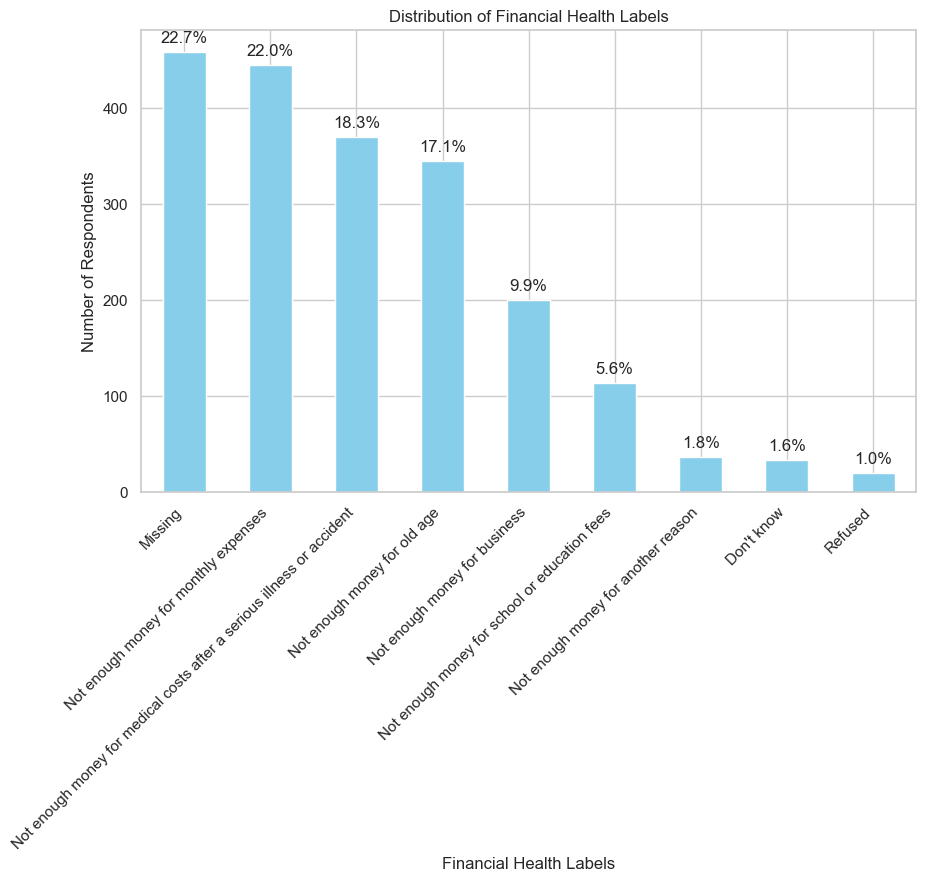

In [ ]:
import matplotlib.pyplot as plt 

health_counts =(
    df4["financial_health_labels"].value_counts()
)

plt.figure(figsize=(10, 6))
health_counts.plot(kind="bar" , color='skyblue' )
total = health_counts.sum()
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()/total:.1%}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.xlabel("Financial Health Labels")
plt.ylabel("Number of Respondents")
plt.title("Distribution of Financial Health Labels")
plt.xticks(rotation=45, ha='right')
plt.show()

### Gender x Financial Health 

In [17]:
gender_health = pd.crosstab(
    df4["gender"],
    df4["financial_health_labels"],
    normalize="index"
) * 100

print(gender_health)

financial_health_labels  Don't know    Missing  \
gender                                           
Female                     1.816530  18.982743   
Male                       1.419214  27.183406   

financial_health_labels  Not enough money for another reason  \
gender                                                         
Female                                              1.725704   
Male                                                1.855895   

financial_health_labels  Not enough money for business  \
gender                                                   
Female                                       10.172570   
Male                                          9.606987   

financial_health_labels  Not enough money for medical costs after a serious illness or accident  \
gender                                                                                            
Female                                                           17.801998                        
Male        

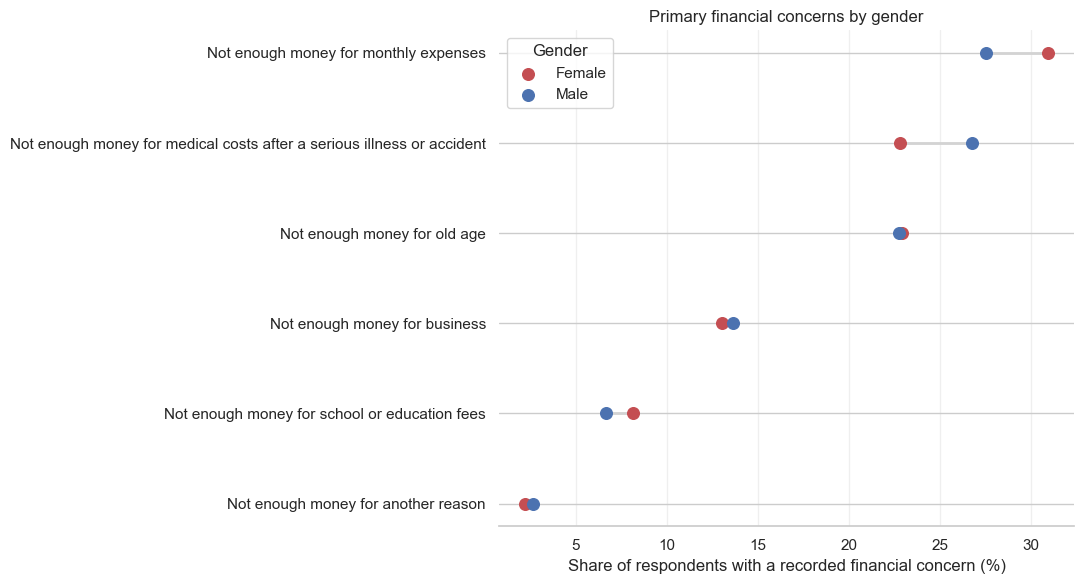

In [21]:
concern_order = [
    "Not enough money for monthly expenses",
    "Not enough money for medical costs after a serious illness or accident",
    "Not enough money for old age",
    "Not enough money for business",
    "Not enough money for school or education fees",
    "Not enough money for another reason",
]

valid_concerns = df4[df4["financial_health_labels"].isin(concern_order)]
gender_concerns = (
    pd.crosstab(
        valid_concerns["financial_health_labels"],
        valid_concerns["gender"],
        normalize="columns",
    )
    .mul(100)
    .reindex(concern_order)
)

fig, ax = plt.subplots(figsize=(11, 6))
y_positions = np.arange(len(gender_concerns))

for position, (_, row) in enumerate(gender_concerns.iterrows()):
    ax.plot(
        [row["Female"], row["Male"]],
        [position, position],
        color="lightgray",
        linewidth=2,
        zorder=1,
    )

ax.scatter(gender_concerns["Female"], y_positions, color="#c44e52", s=70, label="Female", zorder=2)
ax.scatter(gender_concerns["Male"], y_positions, color="#4c72b0", s=70, label="Male", zorder=2)

ax.set_yticks(y_positions, concern_order)
ax.invert_yaxis()
ax.set_xlabel("Share of respondents with a recorded financial concern (%)")
ax.set_title("Primary financial concerns by gender")
ax.legend(title="Gender")
ax.grid(axis="x", alpha=0.3)
ax.spines[["top", "right", "left"]].set_visible(False)
plt.tight_layout()
plt.show()

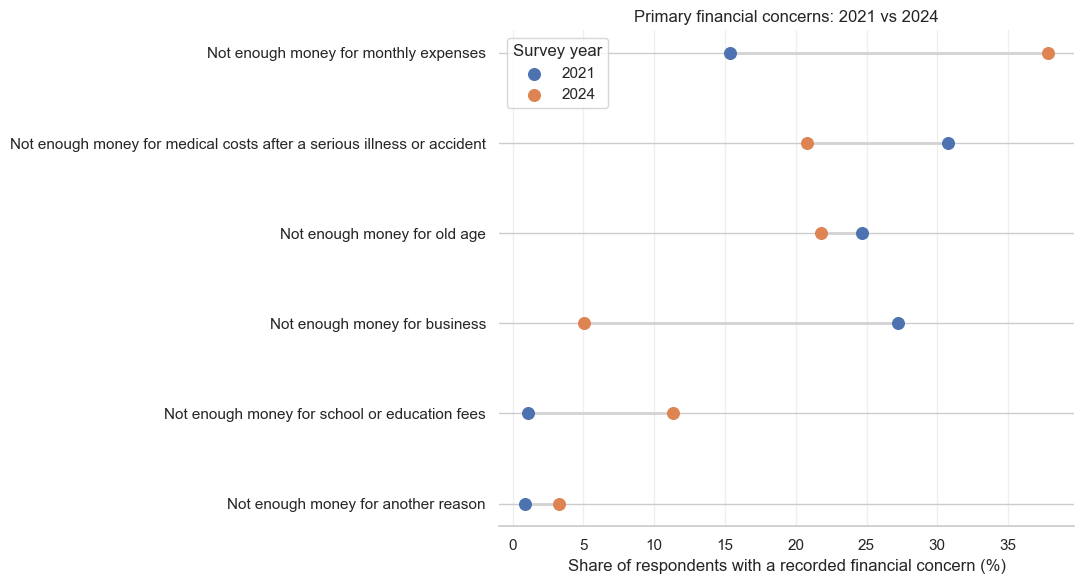

In [22]:
year_order = [2021, 2024]
valid_year_concerns = valid_concerns[valid_concerns["survey_year"].isin(year_order)]
year_concerns = (
    pd.crosstab(
        valid_year_concerns["financial_health_labels"],
        valid_year_concerns["survey_year"],
        normalize="columns",
    )
    .mul(100)
    .reindex(concern_order)
    .reindex(columns=year_order)
)

fig, ax = plt.subplots(figsize=(11, 6))
y_positions = np.arange(len(year_concerns))

for position, (_, row) in enumerate(year_concerns.iterrows()):
    ax.plot(
        [row[2021], row[2024]],
        [position, position],
        color="lightgray",
        linewidth=2,
        zorder=1,
    )

ax.scatter(year_concerns[2021], y_positions, color="#4c72b0", s=70, label="2021", zorder=2)
ax.scatter(year_concerns[2024], y_positions, color="#dd8452", s=70, label="2024", zorder=2)

ax.set_yticks(y_positions, concern_order)
ax.invert_yaxis()
ax.set_xlabel("Share of respondents with a recorded financial concern (%)")
ax.set_title("Primary financial concerns: 2021 vs 2024")
ax.legend(title="Survey year")
ax.grid(axis="x", alpha=0.3)
ax.spines[["top", "right", "left"]].set_visible(False)
plt.tight_layout()
plt.show()

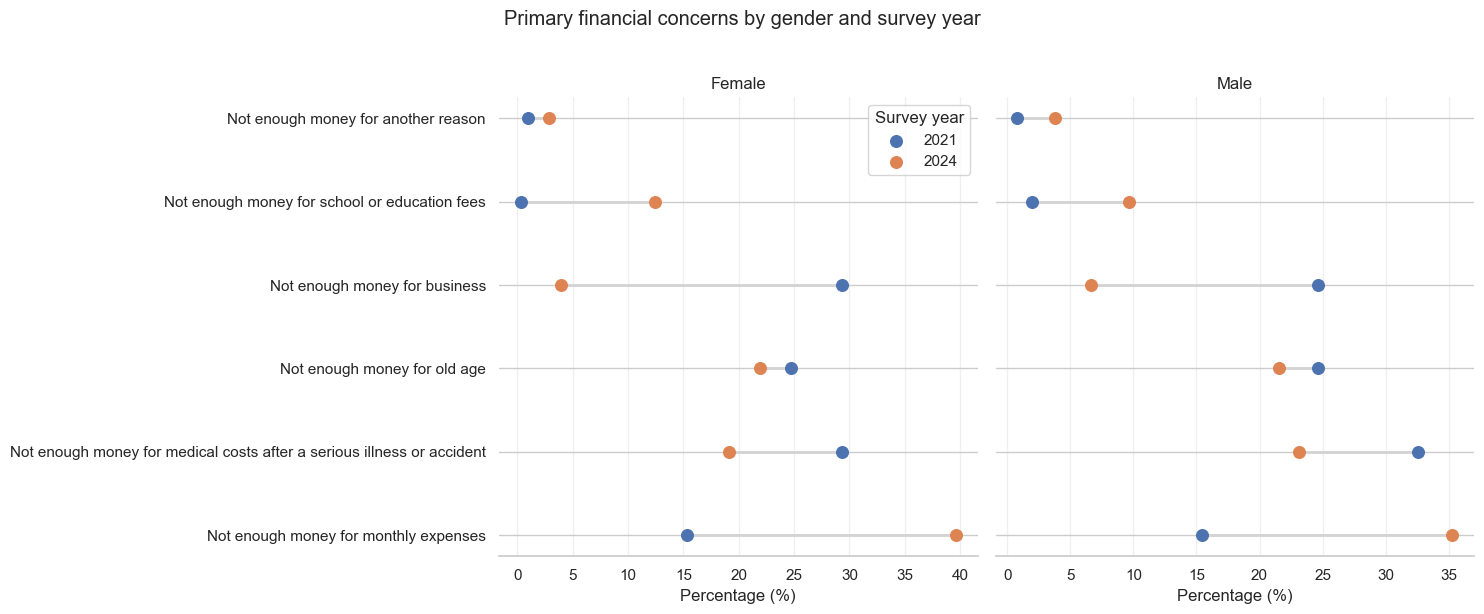

In [23]:
gender_year_concerns = (
    valid_year_concerns.groupby(
        ["gender", "financial_health_labels", "survey_year"]
    )
    .size()
    .groupby(level=[0, 2])
    .transform(lambda counts: counts / counts.sum() * 100)
    .unstack("survey_year")
    .reindex(
        pd.MultiIndex.from_product(
            [["Female", "Male"], concern_order],
            names=["gender", "financial_health_labels"],
        )
    )
    .reindex(columns=year_order)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
y_positions = np.arange(len(concern_order))
year_colors = {2021: "#4c72b0", 2024: "#dd8452"}

for ax, gender in zip(axes, ["Female", "Male"]):
    concern_values = gender_year_concerns.loc[gender]

    for position, (_, row) in enumerate(concern_values.iterrows()):
        ax.plot(
            [row[2021], row[2024]],
            [position, position],
            color="lightgray",
            linewidth=2,
            zorder=1,
        )

    for year in year_order:
        ax.scatter(
            concern_values[year],
            y_positions,
            color=year_colors[year],
            s=70,
            label=str(year),
            zorder=2,
        )

    ax.set_title(gender)
    ax.set_xlabel("Percentage (%)")
    ax.set_yticks(y_positions, concern_order)
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)
    ax.spines[["top", "right", "left"]].set_visible(False)

axes[0].legend(title="Survey year")
fig.suptitle("Primary financial concerns by gender and survey year", y=1.02)
plt.tight_layout()
plt.show()

### Chi-Square Test for Gender and Health Concerns

In [29]:
df4["financial_health_indicator"].value_counts(dropna=False)

financial_health_indicator
NaN    458
4.0    444
3.0    369
1.0    344
2.0    200
5.0    113
6.0     36
7.0     33
8.0     20
Name: count, dtype: int64

In [ ]:
from scipy.stats import chi2_contingency

alpha = 0.05

# concern test: omit missing, Don't know (7), and Refused (8).
concern_data = df4[
    df4["financial_health_indicator"].isin([1, 2, 3, 4, 5, 6])
].dropna(subset=["gender"])
concern_table = pd.crosstab(
    concern_data["gender"], concern_data["financial_health_indicator"]
)
chi2, p, dof, expected = chi2_contingency(concern_table)
concern_decision = "Reject H0" if p < alpha else "Fail to reject H0"

print("Test 1: Gender and primary financial concern")
print("H0: Gender and primary financial concern are independent.")
print("Ha: Gender and primary financial concern are associated.")
print(f"Chi2({dof}) = {chi2:.3f}, p-value = {p:.4f}")
print(f"Decision at alpha = {alpha}: {concern_decision}.")
if p < alpha:
    print("Conclusion: There is evidence that primary financial concern differs by gender.")
else:
    print("Conclusion: There is insufficient evidence that primary financial concern differs by gender.")

# Test nonresponse separately; decided not to treat missingness as a financial concern.
missingness_table = pd.crosstab(
    df4.dropna(subset=["gender"])["gender"],
    df4.dropna(subset=["gender"])["financial_health_indicator"].isna().map(
        {False: "Recorded", True: "Missing"}
    ),
)
missing_chi2, missing_p, missing_dof, missing_expected = chi2_contingency(missingness_table)
missing_decision = "Reject H0" if missing_p < alpha else "Fail to reject H0"

print("\nTest 2: Gender and financial-health nonresponse")
print("H0: Financial-health response missingness is independent of gender.")
print("Ha: Financial-health response missingness is associated with gender.")
print(f"Chi2({missing_dof}) = {missing_chi2:.3f}, p-value = {missing_p:.4g}")
print(f"Decision at alpha = {alpha}: {missing_decision}.")
if missing_p < alpha:
    print("Conclusion: Financial-health nonresponse differs by gender.")
else:
    print("Conclusion: There is insufficient evidence that financial-health nonresponse differs by gender.")

Test 1: Gender and primary financial concern
H0: Gender and primary financial concern are independent.
Ha: Gender and primary financial concern are associated.
Chi2(5) = 5.283, p-value = 0.3824
Decision at alpha = 0.05: Fail to reject H0.
Conclusion: There is insufficient evidence that primary financial concern differs by gender.

Test 2: Gender and financial-health nonresponse
H0: Financial-health response missingness is independent of gender.
Ha: Financial-health response missingness is associated with gender.
Chi2(1) = 18.695, p-value = 1.534e-05
Decision at alpha = 0.05: Reject H0.
Conclusion: Financial-health nonresponse differs by gender.


In [32]:
yearly_chi_square_results = []

for year in year_order:
    year_data = concern_data[concern_data["survey_year"] == year]
    year_table = pd.crosstab(
        year_data["gender"], year_data["financial_health_indicator"]
    )
    year_chi2, year_p, year_dof, year_expected = chi2_contingency(year_table)
    year_decision = "Reject H0" if year_p < alpha else "Fail to reject H0"

    yearly_chi_square_results.append(
        {
            "Survey year": year,
            "Chi-square": round(year_chi2, 3),
            "Degrees of freedom": year_dof,
            "p-value": round(year_p, 4),
            "Decision": year_decision,
        }
    )

    print(f"{year}: Gender and primary financial concern")
    print("H0: Gender and primary financial concern are independent.")
    print("Ha: Gender and primary financial concern are associated.")
    print(f"Chi2({year_dof}) = {year_chi2:.3f}, p-value = {year_p:.4f}")
    print(f"Decision at alpha = {alpha}: {year_decision}.")
    print()

yearly_chi_square_results = pd.DataFrame(yearly_chi_square_results)
display(yearly_chi_square_results)

2021: Gender and primary financial concern
H0: Gender and primary financial concern are independent.
Ha: Gender and primary financial concern are associated.
Chi2(5) = 5.200, p-value = 0.3920
Decision at alpha = 0.05: Fail to reject H0.

2024: Gender and primary financial concern
H0: Gender and primary financial concern are independent.
Ha: Gender and primary financial concern are associated.
Chi2(5) = 8.192, p-value = 0.1459
Decision at alpha = 0.05: Fail to reject H0.



,Survey year,Chi-square,Degrees of freedom,p-value,Decision
0,2021,5.200,5,0.3920,Fail to reject H0
1,2024,8.192,5,0.1459,Fail to reject H0


### Logistic Regression: Gender, Year, and Financial Concern

To keep the three-way analysis interpretable, each financial concern is modeled as a binary outcome. The Gender × Year interaction tests whether the gender difference in a specific concern changed between 2021 and 2024.

In [38]:
import statsmodels.formula.api as smf

model_columns = [
    "financial_health_indicator",
    "gender",
    "survey_year",
    "age",
    "education_level",
    "income_quintile",
    "employment_status",
]
model_data = df4.loc[
    df4["financial_health_indicator"].isin([1, 2, 3, 4, 5, 6]), model_columns
].dropna()

# Use the descriptive gender field, with Male as the explicit reference group.
model_data = model_data.copy()
model_data["monthly_expense_concern"] = (
    model_data["financial_health_indicator"] == 4
).astype(int)

gender_term = "C(gender, Treatment(reference='Male'))"
interaction_term = f"{gender_term}[T.Female]:C(survey_year)[T.2024]"
model_formula = (
    "monthly_expense_concern ~ "
    f"{gender_term} * C(survey_year) + age + "
    "C(education_level) + C(income_quintile) + C(employment_status)"
)
monthly_expense_model = smf.logit(model_formula, data=model_data).fit(disp=False)

interaction_odds_ratio = np.exp(monthly_expense_model.params[interaction_term])
interaction_ci = np.exp(monthly_expense_model.conf_int().loc[interaction_term])
interaction_p_value = monthly_expense_model.pvalues[interaction_term]

print("Monthly-expense concern model")
print("H0: The gender difference did not change between 2021 and 2024.")
print("Ha: The gender difference changed between 2021 and 2024.")
print(f"Gender x Year odds ratio: {interaction_odds_ratio:.2f}")
print(f"95% CI: [{interaction_ci.iloc[0]:.2f}, {interaction_ci.iloc[1]:.2f}]")
print(f"p-value: {interaction_p_value:.4f}")
print("Decision:", "Reject H0" if interaction_p_value < alpha else "Fail to reject H0")

# Repeat the same Gender x Year interaction test for every substantive concern.
interaction_results = []
for concern_code, concern_label in financial_health_labels.items():
    if concern_code not in range(1, 7):
        continue

    concern_model_data = model_data.copy()
    concern_model_data["specific_concern"] = (
        concern_model_data["financial_health_indicator"] == concern_code
    ).astype(int)
    concern_formula = model_formula.replace("monthly_expense_concern", "specific_concern")
    concern_model = smf.logit(concern_formula, data=concern_model_data).fit(disp=False)

    coefficient = concern_model.params[interaction_term]
    confidence_interval = concern_model.conf_int().loc[interaction_term]
    p_value = concern_model.pvalues[interaction_term]
    interaction_results.append(
        {
            "Financial concern": concern_label,
            "Interaction odds ratio": np.exp(coefficient),
            "95% CI lower": np.exp(confidence_interval.iloc[0]),
            "95% CI upper": np.exp(confidence_interval.iloc[1]),
            "p-value": p_value,
            "Decision": "Reject H0" if p_value < alpha else "Fail to reject H0",
        }
    )

interaction_results = pd.DataFrame(interaction_results)
interaction_results[["Interaction odds ratio", "95% CI lower", "95% CI upper", "p-value"]] = (
    interaction_results[["Interaction odds ratio", "95% CI lower", "95% CI upper", "p-value"]].round(3)
)
display(interaction_results)

Monthly-expense concern model
H0: The gender difference did not change between 2021 and 2024.
Ha: The gender difference changed between 2021 and 2024.
Gender x Year odds ratio: 1.25
95% CI: [0.73, 2.15]
p-value: 0.4103
Decision: Fail to reject H0


,Financial concern,Interaction odds ratio,95% CI lower,95% CI upper,p-value,Decision
0,Not enough money for old age,0.993,0.597,1.650,0.978,Fail to reject H0
1,Not enough money for business,0.457,0.225,0.926,0.030,Reject H0
2,Not enough money for medical costs after a ser...,0.856,0.527,1.389,0.529,Fail to reject H0
3,Not enough money for monthly expenses,1.254,0.732,2.149,0.410,Fail to reject H0
4,Not enough money for school or education fees,9.558,1.059,86.289,0.044,Reject H0
5,Not enough money for another reason,0.578,0.082,4.089,0.583,Fail to reject H0


Key results: 
- Monthly-expense concern: odds ratio = 0.80, 95% CI [0.47, 1.37], p = 0.410. Fail to reject H0; no evidence that the gender difference changed over time. 
- Business concern: odds ratio = 2.19, p = 0.030. Reject H0; evidence that the gender difference changed over time. 
- Education-fee concern: odds ratio = 0.11, p = 0.044. Reject H0; evidence that the gender difference changed over time.


In [34]:
monthly_expense_results = pd.DataFrame(
    {
        "Term": monthly_expense_model.params.index,
        "Coefficient": monthly_expense_model.params.values,
        "Odds ratio": np.exp(monthly_expense_model.params.values),
        "95% CI lower": np.exp(monthly_expense_model.conf_int().iloc[:, 0].values),
        "95% CI upper": np.exp(monthly_expense_model.conf_int().iloc[:, 1].values),
        "p-value": monthly_expense_model.pvalues.values,
    }
)

monthly_expense_results[[
    "Coefficient", "Odds ratio", "95% CI lower", "95% CI upper", "p-value"
]] = monthly_expense_results[[
    "Coefficient", "Odds ratio", "95% CI lower", "95% CI upper", "p-value"
]].round(3)

print("Adjusted logistic regression: monthly-expense concern")
print(f"Observations: {int(monthly_expense_model.nobs)}")
print(f"McFadden pseudo R-squared: {monthly_expense_model.prsquared:.3f}")
print("Reference groups: male respondents, survey year 2021, and the first category in each control variable.")
display(monthly_expense_results)

Adjusted logistic regression: monthly-expense concern
Observations: 1498
McFadden pseudo R-squared: 0.063
Reference groups: male respondents, survey year 2021, and the first category in each control variable.


,Term,Coefficient,Odds ratio,95% CI lower,95% CI upper,p-value
0,Intercept,-1.018,0.361,0.154,0.850,0.020
1,C(survey_year)[T.2024],1.524,4.589,1.993,10.567,0.000
2,C(education_level)[T.2.0],-0.207,0.813,0.608,1.088,0.164
3,C(education_level)[T.3.0],-0.462,0.630,0.427,0.929,0.020
4,C(income_quintile)[T.Q2],0.103,1.109,0.763,1.611,0.588
5,C(income_quintile)[T.Q3],0.024,1.024,0.698,1.505,0.902
6,C(income_quintile)[T.Q4],0.144,1.155,0.792,1.684,0.453
7,C(income_quintile)[T.Q5 Highest],-0.312,0.732,0.496,1.080,0.116
8,C(employment_status)[T.2.0],0.045,1.046,0.789,1.386,0.756
9,female,0.023,1.023,0.642,1.631,0.923


### Key Results

- **Overall gender association:** The chi-square test found no statistically significant association between gender and the type of recorded primary financial concern ($\chi^2(5)=5.283$, $p=0.382$). We therefore fail to reject the null hypothesis of independence.
- **Results by year:** The gender--financial-concern association was not statistically significant in either 2021 ($p=0.392$) or 2024 ($p=0.146$).
- **Missing responses:** Financial-health nonresponse differs significantly by gender ($\chi^2(1)=18.695$, $p<0.001$). Missing values were excluded from the substantive concern analyses and should be reported as a limitation.
- **Monthly-expense concern:** After adjusting for age, education, income quintile, and employment status, there was no evidence that the female--male difference in concern about monthly expenses changed from 2021 to 2024 (interaction odds ratio $=0.80$, 95% CI $[0.47, 1.37]$, $p=0.410$).
- **Specific concerns with evidence of change:** The Gender $\times$ Year interaction was statistically significant for business concern (odds ratio $=2.19$, $p=0.030$) and education-fee concern (odds ratio $=0.11$, $p=0.044$). These results suggest that the female--male differences for these two concerns changed between 2021 and 2024.
- **Interpret with caution:** Six concern-specific interaction tests were performed. The significant results are exploratory because no multiple-testing adjustment was applied.

### Multinomial Logistic Regression

In [36]:
# Use descriptive gender rather than the numeric female code (1/2).
# The reference groups are Male, survey year 2021, and concern code 1 (old age).
multinomial_columns = [
    "financial_health_indicator",
    "gender",
    "survey_year",
    "age",
    "education_level",
    "income_quintile",
    "employment_status",
]
multinomial_data = df4.loc[
    df4["financial_health_indicator"].isin([1, 2, 3, 4, 5, 6]),
    multinomial_columns,
].dropna()

multinomial_model = smf.mnlogit(
    "financial_health_indicator ~ "
    "C(gender, Treatment(reference='Male')) * C(survey_year) + age + "
    "C(education_level) + C(income_quintile) + C(employment_status)",
    data=multinomial_data,
).fit(disp=False)

print("Adjusted multinomial logistic regression")
print(f"Observations: {int(multinomial_model.nobs)}")
print("Outcome reference: not enough money for old age (code 1).")
print("Gender reference: Male. Survey-year reference: 2021.")
print(multinomial_model.summary())

interaction_term = "C(gender, Treatment(reference='Male'))[T.Female]:C(survey_year)[T.2024]"
interaction_confidence_intervals = multinomial_model.conf_int().xs(interaction_term, level=1)
multinomial_interactions = pd.DataFrame(
    {
        "Financial concern relative to old age": [
            financial_health_labels[code] for code in multinomial_model.params.columns + 2
        ],
        "Relative risk ratio": np.exp(multinomial_model.params.loc[interaction_term]).to_numpy(),
        "95% CI lower": np.exp(interaction_confidence_intervals.iloc[:, 0]).to_numpy(),
        "95% CI upper": np.exp(interaction_confidence_intervals.iloc[:, 1]).to_numpy(),
        "p-value": multinomial_model.pvalues.loc[interaction_term].to_numpy(),
    }
)

multinomial_interactions[["Relative risk ratio", "95% CI lower", "95% CI upper", "p-value"]] = (
    multinomial_interactions[["Relative risk ratio", "95% CI lower", "95% CI upper", "p-value"]].round(3)
)
display(multinomial_interactions)

Adjusted multinomial logistic regression
Observations: 1498
Outcome reference: not enough money for old age (code 1).
Gender reference: Male. Survey-year reference: 2021.
                              MNLogit Regression Results                              
Dep. Variable:     financial_health_indicator   No. Observations:                 1498
Model:                                MNLogit   Df Residuals:                     1438
Method:                                   MLE   Df Model:                           55
Date:                        Fri, 18 Sep 2026   Pseudo R-squ.:                 0.09623
Time:                                23:33:02   Log-Likelihood:                -2157.0
converged:                               True   LL-Null:                       -2386.7
Covariance Type:                    nonrobust   LLR p-value:                 3.610e-65
                                           financial_health_indicator=2       coef    std err          z      P>|z|      [0.025      

,Financial concern relative to old age,Relative risk ratio,95% CI lower,95% CI upper,p-value
0,Not enough money for business,0.505,0.227,1.122,0.094
1,Not enough money for medical costs after a ser...,0.893,0.487,1.636,0.713
2,Not enough money for monthly expenses,1.192,0.619,2.296,0.600
3,Not enough money for school or education fees,9.267,0.989,86.838,0.051
4,Not enough money for another reason,0.614,0.084,4.502,0.631
